# Hands-On AI for Science
## August 12, Afternoon: Your Data as a Matrix

Every method you will see for the rest of this workshop — regression, neural networks, embeddings, foundation models — uses an identical data structure:

* a matrix $X$ with one **row per sample/datapoint** and one **column per feature** (shape $n \times d$), and
* a vector $y$ of **labels**, one per sample (length $n$).

Your data does not start out looking like that.  It (probably) starts as a spreadsheet or a csv file, possibly quite complicated. Some columns are text, some values are missing, someone typed "Control" three different ways.  This hour is about getting from that spreadsheet to $(X, y)$.  Everything else this week assumes you can do this.

## Setup

Before anything else, the cell below checks that this notebook has what it needs: the required packages, and the data/homework files that ship with the workshop repository.  **If anything prints MISSING, fix it now, before going further.**

* A MISSING *package* under Anaconda usually means Anaconda isn't the Python running this notebook — ask an instructor.
* A MISSING *file* usually means Jupyter was started in the wrong folder.  Everything in this workshop assumes the notebook is opened from the repository's `lectures` folder (see the first notebook, `a12am_python.ipynb`, for how the repository is downloaded).
* After installing anything, always **restart the kernel** (Kernel → Restart Kernel) and re-run from the top.

In [ ]:
import importlib.util, os

packages = ['numpy', 'pandas', 'matplotlib', 'scipy', 'sklearn']
files = ['a12pm_measurements.csv', 'a12pm_mouse_metadata.csv', 'a12pm_hw2.py']

for pkg in packages:
    print(f'{pkg:30s}', 'OK' if importlib.util.find_spec(pkg) is not None else 'MISSING')
for f in files:
    print(f'{f:30s}', 'OK' if os.path.exists(f) else 'MISSING')


1. [Loading data with pandas](#loading)
1. [Inspecting what you loaded](#inspecting)
1. [Cleaning](#cleaning)
1. [Selecting and filtering](#selecting)
1. [Missing data](#missing)
1. [Group summaries with groupby](#groupby)
1. [Joining tables with merge](#merge)
1. [DataFrame → numpy](#bridge)
1. [scipy.stats: statistics in python](#scipy)
1. [scikit-learn in ten minutes](#sklearn)
1. [Where to go for your own field](#signposts)
1. [Homework](#homework)

<a id="loading"></a>

## 1. Loading data with pandas

<a href="https://pandas.pydata.org/">pandas</a> is the standard Python tool for tabular data — data that lives in rows and columns. If you are familiar with R, it's just like that. Pandas comes with Anaconda, so you already have it if you followed the instructions from Lecture 1.  The standard nickname for pandas is `pd`:

In [29]:
import numpy as np
import pandas as pd

This repository directory contains a small (fake, but realistic) lab dataset: gene expression measurements from 60 mice, 5 tissue samples per mouse, half the mice given a treatment.  It has the kinds of problems representative of real datasets.  Load it with `read_csv`:

In [30]:
df = pd.read_csv('a12pm_measurements.csv')
df.head()

,sample_id,mouse_id,condition,gene_a,gene_b,gene_c,gene_d
0,s001,m001,control,4.530,2.100,10.314,5.548
1,s002,m001,Control,3.654,2.172,14.907,6.11
2,s003,m001,control,3.868,3.255,8.838,5.952
3,s004,m001,control,7.340,2.502,14.560,7.683
4,s005,m001,control,4.433,4.372,11.965,9.291


`df` is a **DataFrame** — pandas' central object.  Think of it as a spreadsheet that Python can talk to: unlike a numpy array, its columns have **names**, and different columns can hold different types (text, numbers, dates).

`head()` shows the first five rows.  `shape` tells you how big it is:

In [31]:
df.shape

(300, 7)

<a id="inspecting"></a>

## 2. Inspecting what you loaded

**Never trust a freshly loaded file.**  Three commands tell you most of what you need to know.  First, `dtypes` — what type is each column?

In [32]:
df.dtypes

sample_id        str
mouse_id         str
condition        str
gene_a       float64
gene_b       float64
gene_c       float64
gene_d           str
dtype: object

Look at `gene_d`.  The other gene columns are `float64` (numbers), but `gene_d` is not — pandas is storing it as **text**.  Why?  Because a few entries in that column say `n.d.` ("not detected" — a lab-notebook habit), and one text entry is enough to turn the whole column into text.  We will fix it in a moment.

Next, `describe` — summary statistics for every numeric column:

In [33]:
df.describe()

,gene_a,gene_b,gene_c
count,285.000000,285.000000,285.000000
mean,5.476909,2.813112,11.831586
std,1.236902,1.048852,2.007095
min,2.249000,-0.342000,5.258000
25%,4.594000,2.124000,10.546000
50%,5.545000,2.837000,11.817000
75%,6.361000,3.527000,13.280000
max,8.524000,5.776000,17.672000


(Notice `gene_d` doesn't appear — pandas doesn't compute statistics on text.)

Third: how much is missing?  `isna()` marks every missing cell, and `.sum()` counts them per column:

In [34]:
df.isna().sum()

sample_id     0
mouse_id      0
condition     0
gene_a       15
gene_b       15
gene_c       15
gene_d        0
dtype: int64

Finally, for any categorical column, always look at `value_counts()`:

In [35]:
df['condition'].value_counts()

condition
control       41
treatment     41
CONTROL       40
control       39
Treatment     38
TREATMENT     36
treatment     35
Control       30
Name: count, dtype: int64

There are only two experimental conditions, but the computer sees eight different labels — `control`, `Control`, `CONTROL`, and a `control ` with a trailing space you can't even see.  A human reads these as the same word.  **Software does not.**  This single problem — same category, different strings — has ruined more analyses than any other item in this notebook.

<a id="cleaning"></a>

## 3. Cleaning

We can easily fix the issues with the dataset. First, normalize the condition labels: lowercase them and strip surrounding whitespace.  The `.str` accessor applies a string operation to the whole column at once:

In [36]:
df['condition'] = df['condition'].str.lower().str.strip()
df['condition'].value_counts()

condition
control      150
treatment    150
Name: count, dtype: int64

Two clean groups of 150.

Second, `gene_d`: convert it to numbers with `pd.to_numeric`.  The option `errors='coerce'` says: anything that can't be parsed as a number (like `n.d.`) becomes NaN — which is the truth, since those values were not detected:

In [37]:
df['gene_d'] = pd.to_numeric(df['gene_d'], errors='coerce')
df.dtypes

sample_id        str
mouse_id         str
condition        str
gene_a       float64
gene_b       float64
gene_c       float64
gene_d       float64
dtype: object

<a id="selecting"></a>

## 4. Selecting and filtering

One column (this gives you a **Series** — a single labeled column):

In [38]:
df['gene_a']

0      4.530
1      3.654
2      3.868
3      7.340
4      4.433
       ...  
295    5.890
296    7.030
297    3.781
298    6.231
299    5.215
Name: gene_a, Length: 300, dtype: float64

Several columns — note the double brackets (you are passing a *list* of names):

In [39]:
df[['gene_a', 'gene_b']].head()

,gene_a,gene_b
0,4.530,2.100
1,3.654,2.172
2,3.868,3.255
3,7.340,2.502
4,4.433,4.372


Rows are selected two ways.  `iloc` selects by **position** (like numpy indexing), `loc` by **label and condition**:

In [40]:
print(df.iloc[0])       # first row
df.loc[df['gene_a'] > 7].head()   # all rows where gene_a > 7

sample_id       s001
mouse_id        m001
condition    control
gene_a          4.53
gene_b           2.1
gene_c        10.314
gene_d         5.548
Name: 0, dtype: object


,sample_id,mouse_id,condition,gene_a,gene_b,gene_c,gene_d
3,s004,m001,control,7.340,2.502,14.560,7.683
12,s013,m003,control,7.083,2.316,13.770,8.419
39,s040,m008,control,7.353,3.794,12.986,5.316
51,s052,m011,control,7.684,3.527,11.976,NaN
108,s109,m022,control,7.009,2.607,14.401,8.665


That second pattern — a True/False condition inside `df.loc[...]` — is the pandas equivalent of "SELECT ... WHERE" (if you are familiar with database terminology), and you will use it constantly:

In [41]:
treated = df.loc[df['condition'] == 'treatment']
control = df.loc[df['condition'] == 'control']
print(len(treated), 'treated samples;', len(control), 'control samples')

150 treated samples; 150 control samples


<a id="missing"></a>

## 5. Missing data

Datasets often have missing data. What you do about it is a research design question: your choice depends on *why* the data is missing:

1. **Drop the rows** (`dropna`).  Defensible when little is missing and it's missing at random.  Costs you samples.
2. **Fill with a neutral value** (`fillna`), e.g. the column median.  Defensible when you must keep every row.  Invents data — say so in your methods section.
3. **Leave it and use methods that tolerate NaN** (e.g. `np.nanmean`, and most of `scipy.stats` has `nan_policy` options).

What is **never** defensible is not knowing which one you did, not having a reason for your choice, and not reporting what choice you made.

In [42]:
print('rows before dropna:', len(df))
print('rows after dropna: ', len(df.dropna()))
print('gene_a median-filled mean:', df['gene_a'].fillna(df['gene_a'].median()).mean().round(3))

rows before dropna: 300
rows after dropna:  250
gene_a median-filled mean: 5.48


<a id="groupby"></a>

## 6. Group summaries with groupby

We usually want to summarize our data, such as getting the "Mean expression per condition". Once you have your df set up, doing this in pandas is one line. `groupby` splits the table by a categorical column, applies a computation to each group, and reassembles the result:

In [43]:
df.groupby('condition')['gene_a'].mean()

condition
control      4.849965
treatment    6.117191
Name: gene_a, dtype: float64

In [44]:
gene_cols = ['gene_a', 'gene_b', 'gene_c', 'gene_d']
df.groupby('condition')[gene_cols].mean()

,gene_a,gene_b,gene_c,gene_d
condition,,,,
control,4.849965,2.787191,12.162529,6.959868
treatment,6.117191,2.838493,11.512055,7.439926


Reading across that table: `gene_a` looks strongly affected by treatment, `gene_b` looks untouched.  In Section 9 we'll ask whether the difference is statistically credible.

Also, pandas connects straight back to the matplotlib we used earlier.  Every DataFrame and Series has a `.plot` accessor. You can use `.plot.bar()`, `.plot.hist()`, `.plot.scatter()` to draw the table it's called on, labels and all.  So a plot of the table we just made is one line:

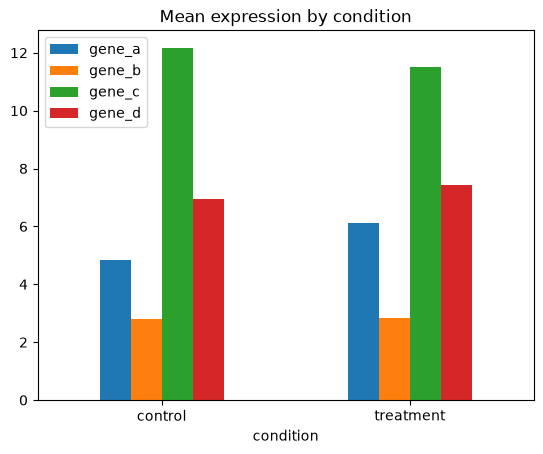

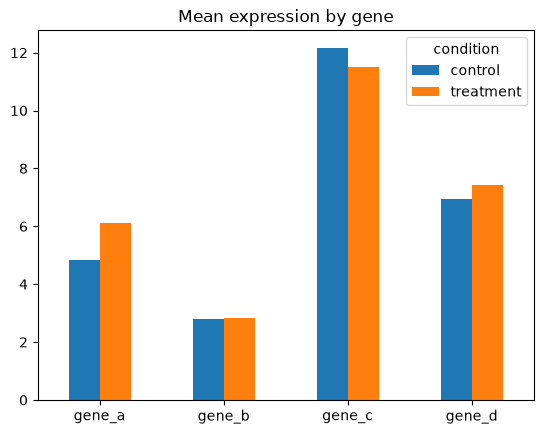

In [61]:
df.groupby('condition')[gene_cols].mean().plot.bar(title='Mean expression by condition', rot=0);
df.groupby('condition')[gene_cols].mean().T.plot.bar(title='Mean expression by gene', rot=0);

<a id="merge"></a>

## 7. Joining tables with merge

Real data often lives in **more than one data file or table**.  Here, we have per-mouse information (sex, age, batch) that is in a separate file, because it was recorded once per mouse, not once per sample:

In [46]:
metadata = pd.read_csv('a12pm_mouse_metadata.csv')
metadata.head()

,mouse_id,sex,age_weeks,batch
0,m001,M,29,batch1
1,m002,F,12,batch1
2,m003,F,28,batch1
3,m004,M,27,batch1
4,m005,F,29,batch1


`merge` joins two tables on a shared key column — here `mouse_id`.  Every sample row picks up its mouse's metadata.  We give the merged table a **new name**, `df_full`, so this cell is safe to re-run — merging a table into itself a second time would create duplicate columns:

In [47]:
df_full = df.merge(metadata, on='mouse_id')
df_full.head()

,sample_id,mouse_id,condition,gene_a,gene_b,gene_c,gene_d,sex,age_weeks,batch
0,s001,m001,control,4.530,2.100,10.314,5.548,M,29,batch1
1,s002,m001,control,3.654,2.172,14.907,6.110,M,29,batch1
2,s003,m001,control,3.868,3.255,8.838,5.952,M,29,batch1
3,s004,m001,control,7.340,2.502,14.560,7.683,M,29,batch1
4,s005,m001,control,4.433,4.372,11.965,9.291,M,29,batch1


We won't go deeper today, but `merge` is worth additional study. It is how measurement files combine with sample sheets. It has options (`how='left'`, `'inner'`, `'outer'`) that control what happens to rows that don't match.  See the <a href="https://pandas.pydata.org/docs/user_guide/merging.html">pandas merging guide</a>.

<a id="bridge"></a>

## 8. DataFrame → numpy

**This is the most important cell in the notebook.**  Models don't directly take pandas DataFrames as input. They take numeric arrays (e.g. numpy arrays) as input.

1. choose your feature columns,
2. drop rows with missing features (a deliberate, visible choice — option 1 from Section 5),
3. `.to_numpy()` for the features → $X$,
4. pull out the label column → $y$.

In [48]:
feature_cols = ['gene_a', 'gene_b', 'gene_c', 'gene_d']

clean = df_full.dropna(subset=feature_cols)
X = clean[feature_cols].to_numpy()
y = (clean['condition'] == 'treatment').to_numpy().astype(int)

print('X:', X.shape, X.dtype, '   y:', y.shape, y.dtype)
print(X[0:5,:])  # print the first five rows in X
print(X[-5:,:])  # print the last five rows in X
print('samples per class:', np.bincount(y))
print(y[0:5])  # print the first five rows in y
print(y[-5:])  # print the last five rows in y

X: (250, 4) float64    y: (250,) int64
[[ 4.53   2.1   10.314  5.548]
 [ 3.654  2.172 14.907  6.11 ]
 [ 3.868  3.255  8.838  5.952]
 [ 7.34   2.502 14.56   7.683]
 [ 4.433  4.372 11.965  9.291]]
[[ 5.89   3.567 11.101  6.35 ]
 [ 7.03   1.875 13.368  5.507]
 [ 3.781  2.148 12.596  8.993]
 [ 6.231  0.223 13.09   5.161]
 [ 5.215  4.494 14.133  5.763]]
samples per class: [120 130]
[0 0 0 0 0]
[1 1 1 1 1]


250 samples, 4 features, and a 0/1 label for control/treatment.  From here on, everything in this workshop — today's t-test, tomorrow's neural network, Friday's protein language model — is some function of an $(X, y)$ pair shaped exactly like this.

<a id="scipy"></a>

## 9. scipy.stats: statistics in python

<a href="https://scipy.org/">scipy</a> is numpy's big sibling: a general toolbox of scientific computing routines, organized into submodules. These include scipy.stats (statistical tests and distributions), scipy.optimize (curve fitting), scipy.signal (filtering and spectral analysis), scipy.spatial (distances between data points), and scipy.ndimage (image processing), among others. Today we only need one of them: scipy.stats contains some common statistical functions: t-tests, correlations, ANOVA, and hundreds more. A lot of the same stuff as R; only the syntax changes.

We will use scipy.stats to do some simple statistics on our dataset. Is the treatment effect on `gene_a` credible?

In [49]:
from scipy import stats

a = control['gene_a'].dropna()
b = treated['gene_a'].dropna()
result = stats.ttest_ind(a, b)
print('gene_a: t =', result.statistic.round(2), '  p =', result.pvalue)

gene_a: t = -10.06   p = 1.5228096556701556e-20


We can test all four genes and then correct for multiple comparisons. `false_discovery_control` is the Benjamini–Hochberg FDR correction commonly used in genomics:

In [50]:
pvals = []
for g in gene_cols:
    res = stats.ttest_ind(control[g].dropna(), treated[g].dropna())
    pvals.append(res.pvalue)

qvals = stats.false_discovery_control(pvals)

for g, p, q in zip(gene_cols, pvals, qvals):
    print(f'{g}:  p = {p:.2e}   FDR-adjusted p = {q:.2e}')

gene_a:  p = 1.52e-20   FDR-adjusted p = 6.09e-20
gene_b:  p = 6.80e-01   FDR-adjusted p = 6.80e-01
gene_c:  p = 6.03e-03   FDR-adjusted p = 9.53e-03
gene_d:  p = 7.15e-03   FDR-adjusted p = 9.53e-03


Notice the correction barely affects the very strong (A) and very weak results (B). It's the borderline p-values (C and D) that are affected most.

Correlations work the same way — `stats.pearsonr` and `stats.spearmanr`.  For example, `gene_c` is positively associated with age:

In [51]:
ok = df_full.dropna(subset=['gene_c'])
r, p = stats.pearsonr(ok['gene_c'], ok['age_weeks'])
print('gene_c vs age:  r =', r.round(3), '  p =', f'{p:.1e}')

gene_c vs age:  r = 0.264   p = 6.1e-06


One more scipy module to remember for later: `scipy.spatial.distance` (`pdist`, `cosine`) computes distances between rows of a matrix.  **We will want it tomorrow afternoon**, when we ask which samples — and which words, and which proteins — are *similar* to each other.

<a id="sklearn"></a>

## 10. scikit-learn in ten minutes

<a href="https://scikit-learn.org/">scikit-learn</a> is the standard Python library for classical machine learning.  Today we will only give a very short summary. But scikit-learn is nice, because it contains a huge number of different kinds of machine learning models. And they all rely on the same data structure shape (the one we've been using), and follow the same three-step pattern:

```
model.fit(X_train, y_train)      # learn from data
model.predict(X_test)            # apply to new data
model.score(X_test, y_test)      # how well did it do?
```

Remember that pattern. **The meaning of these steps is a focus of tomorrow morning's sessions.**

Two preliminary steps before any model uses the data.  First, split the samples into a **training set** (the model learns from these) and a held-out **test set** (we grade the model on these).  Second, **normalize** the features.  `StandardScaler` z-scores each feature column (subtract the column's mean and divide by its standard deviation), so every feature ends up with mean 0 and standard deviation 1.  We do this because models like logistic regression are sensitive to the scale of the features.  Without it, a gene measured in the thousands would dominate a model over one measured in fractions, even if the effect of the latter was greater.

For StandardScaler, `fit` just means "memorize each column's mean and std". Then `transform` applies the shift-and-divide.  Notice that we compute those means and stds from the *training* rows only — why that matters is for Thursday.

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

scaler = StandardScaler().fit(X_train)   # fit on the training part only -- why? Thursday.
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print('training samples:', X_train.shape[0], '   test samples:', X_test.shape[0])

training samples: 187    test samples: 63


Now the model — the three-step pattern in action:

In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_s, y_train)
print('accuracy on held-out samples:', round(model.score(X_test_s, y_test), 3))

accuracy on held-out samples: 0.841


A classifier that tells treated from control samples about 84% of the time, in five lines.  Two questions we might have:

* Why did we split the data before fitting?
* Is 84% *good*?

Both are tomorrow's 11am session.

Next, we can see how the fit-predict-score pattern is the same across many different kinds of models. Four models, four very different modeling philosophies, same three steps in python:

In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

models = [
    LogisticRegression(),                      # a linear decision rule
    KNeighborsClassifier(),                    # vote of the 5 most similar samples
    RandomForestClassifier(random_state=0),    # ensemble of decision trees
    LinearDiscriminantAnalysis(),              # the LDA of classical multivariate statistics
]

for model in models:
    model.fit(X_train_s, y_train)
    print(f'{type(model).__name__:30s} accuracy: {model.score(X_test_s, y_test):.3f}')

LogisticRegression             accuracy: 0.841
KNeighborsClassifier           accuracy: 0.778
RandomForestClassifier         accuracy: 0.825
LinearDiscriminantAnalysis     accuracy: 0.841


What you should **not** conclude from this table is that the highest number is "the best model" — with only 63 test samples, these differences are probably noise.  How to compare models honestly is something we will discuss tomorrow.

<a id="signposts"></a>

## 11. Where to go for your own field

| If you work with... | Look at |
|---|---|
| classical statistics, mixed models, GLMs | <a href="https://www.statsmodels.org/">statsmodels</a> (R-like formulas: `y ~ condition + age`) |
| sequences, alignments, genomics files | <a href="https://biopython.org/">biopython</a> |
| single-cell RNA-seq | <a href="https://scanpy.readthedocs.io/">scanpy</a> |
| EEG / MEG | <a href="https://mne.tools/">MNE</a> |
| MRI / neuroimaging | <a href="https://nipy.org/nibabel/">nibabel</a> |

Three habits that make any of these learnable:

1. **Read the Quick Start / tutorial page first**, not the API reference.  Every good library has one; it's written for exactly you.
2. **Install with one tool.**  Not all of them come pre-installed with Anaconda. But they are easy to install. You have two ways to do it: `conda install` and `pip install`.  Mixing them in one environment is the most common way scientific Python setups break.  Simple rule for this week: try `conda install` first; if the package isn't found, use `pip install`; when something is deeply broken, deleting and recreating the environment is cheaper than debugging it.
3. **Every library speaks numpy.**  Whatever field-specific loader you use, somewhere there is an array with your numbers in it — and from there, everything in this notebook applies.

<a id="homework"></a>

## Homework

The homework asks you to package what you just did into three reusable functions — the same three you will need for your own data.  As before, open the file `a12pm_hw2.py` from the file listing in one of your browser tabs, delete the line that says `raise RuntimeError("You need to write this part!")`, and fill in your own code.

Start with `load_and_clean` and `to_feature_matrix` — we'll work on those here in the session.  `group_means` is yours to finish afterward.

In [55]:
import a12pm_hw2, importlib
importlib.reload(a12pm_hw2)
help(a12pm_hw2)

Help on module a12pm_hw2:

NAME
    a12pm_hw2

FUNCTIONS
    group_means(df, by, value)
        Compute the mean of one column, separately for each level of another.

        @param:
        df (DataFrame): the data table
        by (str): name of the categorical column to group by
        value (str): name of the numeric column to average

        @return:
        means (Series): the mean of `value` for each level of `by`, indexed by
          the levels of `by` -- i.e., the result of df.groupby(by)[value].mean()

    load_and_clean(path)
        Load a messy measurements CSV and clean it up.

        @param:
        path (str): path to a CSV file formatted like a12pm_measurements.csv

        @return:
        df (DataFrame): the loaded table, with two problems fixed:
          1. The `condition` column is lowercased and stripped of surrounding
             whitespace, so that it contains exactly two values:
             'control' and 'treatment'.
          2. The `gene_d` column is c

**Check `load_and_clean`.**  When it works, this should print two conditions with 150 samples each, and `gene_d` should have a float dtype:

In [56]:
importlib.reload(a12pm_hw2)

df2 = a12pm_hw2.load_and_clean('a12pm_measurements.csv')
print(df2['condition'].value_counts())
print('gene_d dtype:', df2['gene_d'].dtype)
print('rows:', len(df2))

RuntimeError: You need to write this part!

**Check `to_feature_matrix`.**  Expected output:

```
X: (250, 4) float64    y: (250,)
labels: ['control' 'treatment']
```

In [57]:
importlib.reload(a12pm_hw2)

df2 = a12pm_hw2.load_and_clean('a12pm_measurements.csv')
X2, y2 = a12pm_hw2.to_feature_matrix(df2, ['gene_a','gene_b','gene_c','gene_d'], 'condition')
print('X:', X2.shape, X2.dtype, '   y:', y2.shape)
print('labels:', np.unique(y2))

RuntimeError: You need to write this part!

**Check `group_means`.**  This should match the Section 6 table's `gene_a` column (control ≈ 4.85, treatment ≈ 6.12):

In [58]:
importlib.reload(a12pm_hw2)

df2 = a12pm_hw2.load_and_clean('a12pm_measurements.csv')
print(a12pm_hw2.group_means(df2, 'condition', 'gene_a'))

RuntimeError: You need to write this part!

**The real homework** starts after the workshop: do this to one of your own spreadsheets.  `load_and_clean` will need changing — your mess is different from our mess — but the shape of the function is exactly the same.